In [1]:
import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_ID = "turkiye-border-wellbeing-2026"

ee.Authenticate()
ee.Initialize(project=PROJECT_ID)

print("Earth Engine ready.")

Mounted at /content/drive
Earth Engine ready.


In [3]:
ROOT = Path("/content/drive/MyDrive/turkiye-border-wellbeing")

INTERIM = ROOT / "data/interim"
PROCESSED = ROOT / "data/processed"
RAW_BUILT = ROOT / "data/raw/built_environment"
FIGURES = ROOT / "figures/appendix"

RAW_BUILT.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

In [4]:
grid = gpd.read_file(
    INTERIM / "grid_1km_master.gpkg"
)

grid_wgs84 = grid[
    ["grid_id", "geometry"]
].to_crs("EPSG:4326")

print("Grid cells:", len(grid_wgs84))

Grid cells: 19001


In [5]:
ghsl = ee.ImageCollection(
    "JRC/GHSL/P2023A/GHS_BUILT_S"
)

print("Images:", ghsl.size().getInfo())
print(
    ghsl.aggregate_array("system:index").getInfo()
)

Images: 12
['1975', '1980', '1985', '1990', '1995', '2000', '2005', '2010', '2015', '2020', '2025', '2030']


In [6]:
img_2015 = ghsl.filter(
    ee.Filter.eq("system:index", "2015")
).first()

img_2020 = ghsl.filter(
    ee.Filter.eq("system:index", "2020")
).first()

img_2025 = ghsl.filter(
    ee.Filter.eq("system:index", "2025")
).first()

In [7]:
print(
    ee.Image(img_2020)
    .bandNames()
    .getInfo()
)

['built_surface', 'built_surface_nres']


In [8]:
built_2015 = ee.Image(img_2015).select("built_surface").rename("built_2015")
built_2020 = ee.Image(img_2020).select("built_surface").rename("built_2020")
built_2025 = ee.Image(img_2025).select("built_surface").rename("built_2025")

built_stack = ee.Image.cat([
    built_2015,
    built_2020,
    built_2025
])

print(built_stack.bandNames().getInfo())

['built_2015', 'built_2020', 'built_2025']


In [9]:
BATCH_SIZE = 500

test_batch = (
    grid_wgs84
    .iloc[:BATCH_SIZE]
    [["grid_id", "geometry"]]
    .copy()
)

test_ee = geemap.geopandas_to_ee(test_batch)

test_stats = built_stack.reduceRegions(
    collection=test_ee,
    reducer=ee.Reducer.sum(),
    scale=100,
    tileScale=4
)

test_df = geemap.ee_to_df(test_stats)

print("Shape:", test_df.shape)
print(test_df.columns.tolist())
test_df.head()

Shape: (500, 4)
['built_2015', 'built_2020', 'built_2025', 'grid_id']


,built_2015,built_2020,built_2025,grid_id
0,0.000000,0.000000,0.000000,G000001
1,323.501961,331.980392,331.980392,G000002
2,0.000000,0.000000,0.000000,G000003
3,0.000000,0.000000,0.000000,G000004
4,0.000000,0.000000,0.000000,G000005


In [10]:
all_batches = []

for start in range(0, len(grid_wgs84), BATCH_SIZE):

    end = min(start + BATCH_SIZE, len(grid_wgs84))

    print(
        f"Processing grids {start:,}–{end:,} "
        f"of {len(grid_wgs84):,}"
    )

    batch_gdf = (
        grid_wgs84
        .iloc[start:end]
        [["grid_id", "geometry"]]
        .copy()
    )

    batch_ee = geemap.geopandas_to_ee(batch_gdf)

    batch_stats = built_stack.reduceRegions(
        collection=batch_ee,
        reducer=ee.Reducer.sum(),
        scale=100,
        tileScale=4
    )

    batch_df = geemap.ee_to_df(batch_stats)

    all_batches.append(batch_df)

print("All batches completed.")

Processing grids 0–500 of 19,001
Processing grids 500–1,000 of 19,001
Processing grids 1,000–1,500 of 19,001
Processing grids 1,500–2,000 of 19,001
Processing grids 2,000–2,500 of 19,001
Processing grids 2,500–3,000 of 19,001
Processing grids 3,000–3,500 of 19,001
Processing grids 3,500–4,000 of 19,001
Processing grids 4,000–4,500 of 19,001
Processing grids 4,500–5,000 of 19,001
Processing grids 5,000–5,500 of 19,001
Processing grids 5,500–6,000 of 19,001
Processing grids 6,000–6,500 of 19,001
Processing grids 6,500–7,000 of 19,001
Processing grids 7,000–7,500 of 19,001
Processing grids 7,500–8,000 of 19,001
Processing grids 8,000–8,500 of 19,001
Processing grids 8,500–9,000 of 19,001
Processing grids 9,000–9,500 of 19,001
Processing grids 9,500–10,000 of 19,001
Processing grids 10,000–10,500 of 19,001
Processing grids 10,500–11,000 of 19,001
Processing grids 11,000–11,500 of 19,001
Processing grids 11,500–12,000 of 19,001
Processing grids 12,000–12,500 of 19,001
Processing grids 12,50

In [11]:
built_wide = pd.concat(
    all_batches,
    ignore_index=True
)

print("Rows:", len(built_wide))
print("Columns:", len(built_wide.columns))
print("Unique grid IDs:", built_wide["grid_id"].nunique())

Rows: 19001
Columns: 4
Unique grid IDs: 19001


In [12]:
for year in [2015, 2020, 2025]:

    built_wide[f"built_share_{year}"] = (
        built_wide[f"built_{year}"] / 1_000_000
    )

    built_wide[f"built_pct_{year}"] = (
        built_wide[f"built_share_{year}"] * 100
    )

In [13]:
print(
    built_wide[
        [
            "built_share_2015",
            "built_share_2020",
            "built_share_2025"
        ]
    ].describe()
)

       built_share_2015  built_share_2020  built_share_2025
count      19001.000000      19001.000000      19001.000000
mean           0.005995          0.006545          0.006957
std            0.025977          0.027896          0.028892
min            0.000000          0.000000          0.000000
25%            0.000000          0.000000          0.000000
50%            0.000000          0.000000          0.000000
75%            0.000773          0.000812          0.000866
max            0.429368          0.437740          0.438403


In [14]:


records = []

for _, row in built_wide.iterrows():

    g = row["grid_id"]

    b2015 = row["built_share_2015"]
    b2020 = row["built_share_2020"]
    b2025 = row["built_share_2025"]

    for year in range(2014, 2026):

        if year <= 2015:
            built_share = b2015

        elif year < 2020:
            weight = (year - 2015) / 5
            built_share = (
                b2015 +
                weight * (b2020 - b2015)
            )

        elif year == 2020:
            built_share = b2020

        elif year < 2025:
            weight = (year - 2020) / 5
            built_share = (
                b2020 +
                weight * (b2025 - b2020)
            )

        else:
            built_share = b2025

        records.append({
            "grid_id": g,
            "year": year,
            "built_share": built_share
        })

built_panel = pd.DataFrame(records)

print("Panel observations:", len(built_panel))
print(built_panel.head(15))

Panel observations: 228012
    grid_id  year  built_share
0   G000001  2014     0.000000
1   G000001  2015     0.000000
2   G000001  2016     0.000000
3   G000001  2017     0.000000
4   G000001  2018     0.000000
5   G000001  2019     0.000000
6   G000001  2020     0.000000
7   G000001  2021     0.000000
8   G000001  2022     0.000000
9   G000001  2023     0.000000
10  G000001  2024     0.000000
11  G000001  2025     0.000000
12  G000002  2014     0.000324
13  G000002  2015     0.000324
14  G000002  2016     0.000325


In [15]:
built_panel["built_pct"] = (
    built_panel["built_share"] * 100
)

In [16]:
print(
    built_panel[
        ["built_share", "built_pct"]
    ].describe()
)

print(
    "Missing:",
    built_panel["built_share"]
    .isna()
    .sum()
)

         built_share      built_pct
count  228012.000000  228012.000000
mean        0.006465       0.646478
std         0.027516       2.751551
min         0.000000       0.000000
25%         0.000000       0.000000
50%         0.000000       0.000000
75%         0.000817       0.081726
max         0.438403      43.840345
Missing: 0


In [17]:
built_qc = (
    built_panel
    .groupby("year")
    .agg(
        count=("built_share", "count"),
        missing=("built_share", lambda x: x.isna().sum()),
        mean=("built_share", "mean"),
        median=("built_share", "median"),
        std=("built_share", "std"),
        min=("built_share", "min"),
        max=("built_share", "max")
    )
)

print(built_qc)

      count  missing      mean  median       std  min       max
year                                                           
2014  19001        0  0.005995     0.0  0.025977  0.0  0.429368
2015  19001        0  0.005995     0.0  0.025977  0.0  0.429368
2016  19001        0  0.006105     0.0  0.026347  0.0  0.431042
2017  19001        0  0.006215     0.0  0.026725  0.0  0.432717
2018  19001        0  0.006325     0.0  0.027109  0.0  0.434391
2019  19001        0  0.006435     0.0  0.027500  0.0  0.436066
2020  19001        0  0.006545     0.0  0.027896  0.0  0.437740
2021  19001        0  0.006628     0.0  0.028086  0.0  0.437873
2022  19001        0  0.006710     0.0  0.028280  0.0  0.438005
2023  19001        0  0.006792     0.0  0.028479  0.0  0.438138
2024  19001        0  0.006874     0.0  0.028683  0.0  0.438271
2025  19001        0  0.006957     0.0  0.028892  0.0  0.438403


In [18]:
built_panel_path = (
    PROCESSED /
    "built_environment_grid_year_2014_2025.csv"
)

built_panel.to_csv(
    built_panel_path,
    index=False
)

print("Saved:", built_panel_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/processed/built_environment_grid_year_2014_2025.csv


In [19]:
built_wide_path = (
    INTERIM /
    "ghsl_built_surface_2015_2020_2025.csv"
)

built_wide.to_csv(
    built_wide_path,
    index=False
)

print("Saved:", built_wide_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/ghsl_built_surface_2015_2020_2025.csv


In [20]:
built_qc_path = (
    INTERIM /
    "built_environment_annual_qc_2014_2025.csv"
)

built_qc.to_csv(
    built_qc_path,
    index_label="year"
)

print("Saved:", built_qc_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/built_environment_annual_qc_2014_2025.csv


In [21]:
import json

built_metadata = {
    "dataset": "JRC/GHSL/P2023A/GHS_BUILT_S",
    "main_band": "built_surface",
    "observed_epochs": [2015, 2020, 2025],
    "analysis_period": "2014-2025",
    "source_spatial_resolution": "100 m",
    "analysis_grid": "1 km x 1 km",
    "main_variable": "built_share",
    "definition":
        "Share of each 1 km grid cell covered by GHSL built-up surface",
    "annualization":
        "Linear interpolation between the 2015, 2020 and 2025 GHSL epochs",
    "year_2014":
        "Assigned the 2015 GHSL value; no extrapolated trend imposed before 2015",
    "important_note":
        "Values for non-epoch years are interpolated estimates and are not independent annual satellite observations",
    "grid_count": 19001,
    "panel_observations": 228012
}

metadata_path = (
    INTERIM /
    "built_environment_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        built_metadata,
        f,
        indent=4,
        ensure_ascii=False
    )

print("Saved:", metadata_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/built_environment_metadata.json


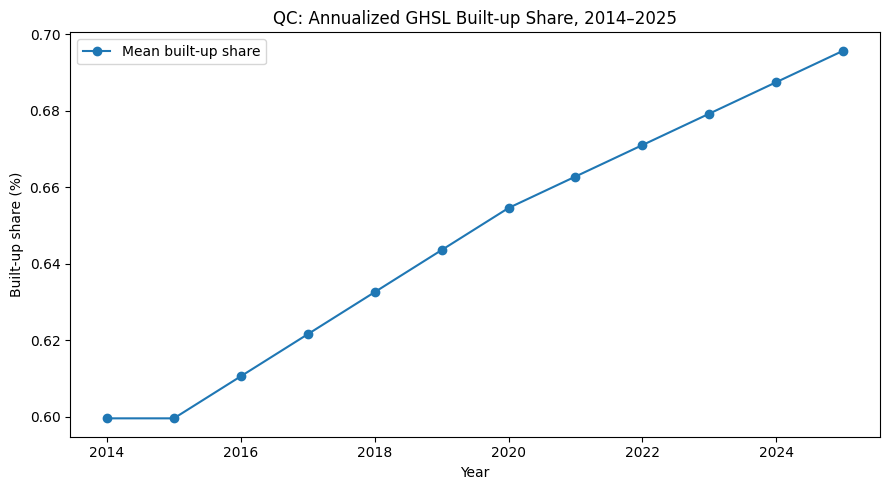

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/figures/appendix/qc_built_environment_trend.png


In [22]:
import matplotlib.pyplot as plt

annual_built = (
    built_panel
    .groupby("year")
    .agg(
        mean_built_share=("built_share", "mean"),
        median_built_share=("built_share", "median")
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    annual_built["year"],
    annual_built["mean_built_share"] * 100,
    marker="o",
    label="Mean built-up share"
)

ax.set_xlabel("Year")
ax.set_ylabel("Built-up share (%)")
ax.set_title("QC: Annualized GHSL Built-up Share, 2014–2025")

ax.legend()

plt.tight_layout()

out = FIGURES / "qc_built_environment_trend.png"

plt.savefig(
    out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", out)

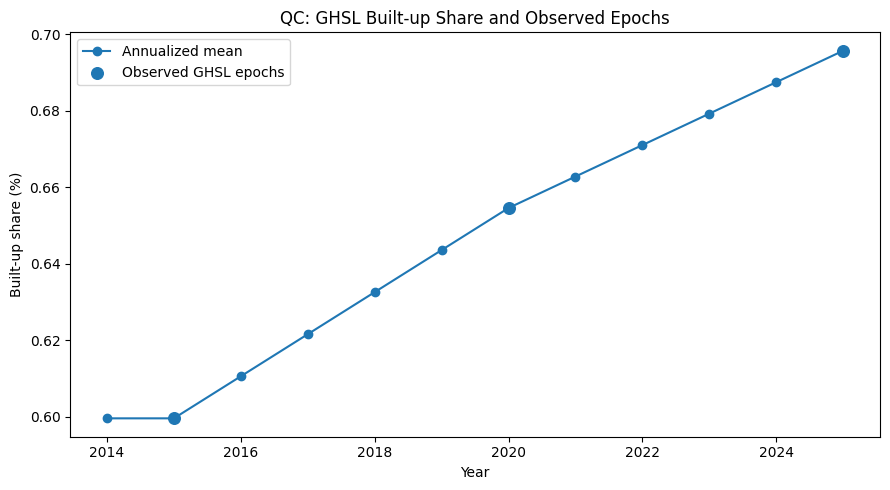

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/figures/appendix/qc_built_environment_epochs.png


In [23]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    annual_built["year"],
    annual_built["mean_built_share"] * 100,
    marker="o",
    label="Annualized mean"
)

observed_years = [2015, 2020, 2025]

obs = annual_built[
    annual_built["year"].isin(observed_years)
]

ax.scatter(
    obs["year"],
    obs["mean_built_share"] * 100,
    s=70,
    label="Observed GHSL epochs"
)

ax.set_xlabel("Year")
ax.set_ylabel("Built-up share (%)")
ax.set_title("QC: GHSL Built-up Share and Observed Epochs")
ax.legend()

plt.tight_layout()

out = FIGURES / "qc_built_environment_epochs.png"

plt.savefig(
    out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", out)